In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv("pacemaker_dataset.csv")

df.head()

,BMI,Smoking,Alcohol,Stroke,Sex,Age_Category,Diabetic,PhysicalActivity,HeartRate,Attack_Label
0,26.239883,Yes,Yes,Yes,Female,40-44,Yes,No,78,0
1,20.199448,Yes,No,Yes,Female,55-59,No,Yes,81,0
2,19.241055,No,No,No,Female,25-29,No,No,80,0
3,31.584593,No,No,Yes,Female,60-64,Yes,Yes,87,2
4,39.422621,Yes,No,No,Male,30-34,No,Yes,62,0


In [3]:
label_cols = [
    "Smoking","Alcohol","Stroke",
    "Sex","Diabetic","PhysicalActivity","Age_Category"
]

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [4]:
X = df.drop("Attack_Label",axis=1)
y = df["Attack_Label"]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X = X.reshape(X.shape[0],1,X.shape[1])

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [5]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [6]:
model = Sequential()

model.add(LSTM(100,return_sequences=True,input_shape=(1,X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(32,activation="relu"))

model.add(Dense(4,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6455 - loss: 0.9731 - val_accuracy: 0.7688 - val_loss: 0.5685
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8067 - loss: 0.4656 - val_accuracy: 0.9169 - val_loss: 0.2851
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8750 - loss: 0.3056 - val_accuracy: 0.9319 - val_loss: 0.1964
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9122 - loss: 0.2252 - val_accuracy: 0.9631 - val_loss: 0.1361
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9205 - loss: 0.1985 - val_accuracy: 0.9600 - val_loss: 0.1182
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9300 - loss: 0.1799 - val_accuracy: 0.9675 - val_loss: 0.1074
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9345 - loss: 0.1646 - val_accuracy: 0.9769 - val_loss: 0.0921
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9377 - loss: 0.1529 - val_accuracy: 0.

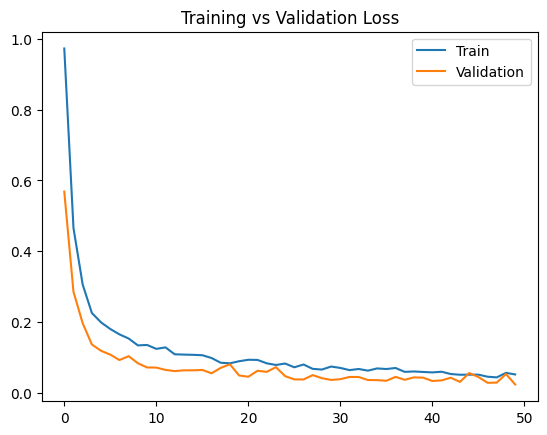

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.legend(["Train","Validation"])
plt.show()

In [10]:
model.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9915 - loss: 0.0234


[0.02340678684413433, 0.9915000200271606]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


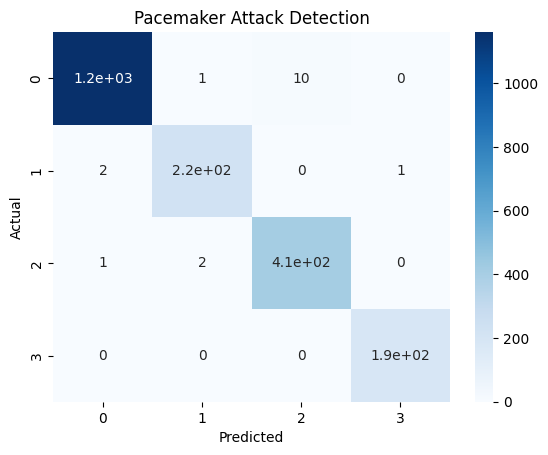

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1171
           1       0.99      0.99      0.99       227
           2       0.98      0.99      0.98       412
           3       0.99      1.00      1.00       190

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)

# Convert y_test back to single integer labels for confusion matrix and classification report
y_test_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_labels, pred)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Pacemaker Attack Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test_labels, pred))

In [13]:
model.save("pacemaker_lstm_model.h5")

Real-Time Simulation

In [19]:
import random
import time

def generate_patient_data():

    bmi = random.uniform(18,40)
    heart_rate = random.randint(60,110)

    sample = [[bmi,0,0,0,1,3,0,1,heart_rate]]

    return sample

In [20]:
while True:

    patient = generate_patient_data()

    patient = scaler.transform(patient)

    patient = patient.reshape(1,1,9)

    prediction = model.predict(patient)

    label = np.argmax(prediction)

    if label != 0:
        print("ALERT: Pacemaker anomaly detected")

    else:
        print("Normal heartbeat")

    time.sleep(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ALERT: Pacemaker anomaly detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ALERT: Pacemaker anomaly detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ALERT: Pacemaker anomaly detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Normal heartbeat


KeyboardInterrupt: 

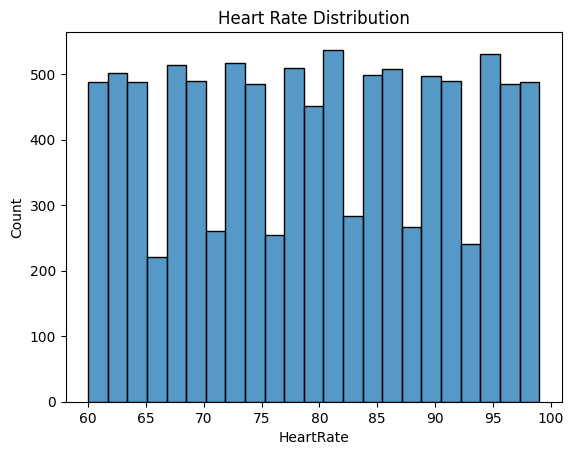

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["HeartRate"])

plt.title("Heart Rate Distribution")
plt.show()